In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження результатів передбачення
results = pd.read_csv('../data/prediction_results.csv')
print("Розмір даних з результатами:", results.shape)


Розмір даних з результатами: (121, 34)


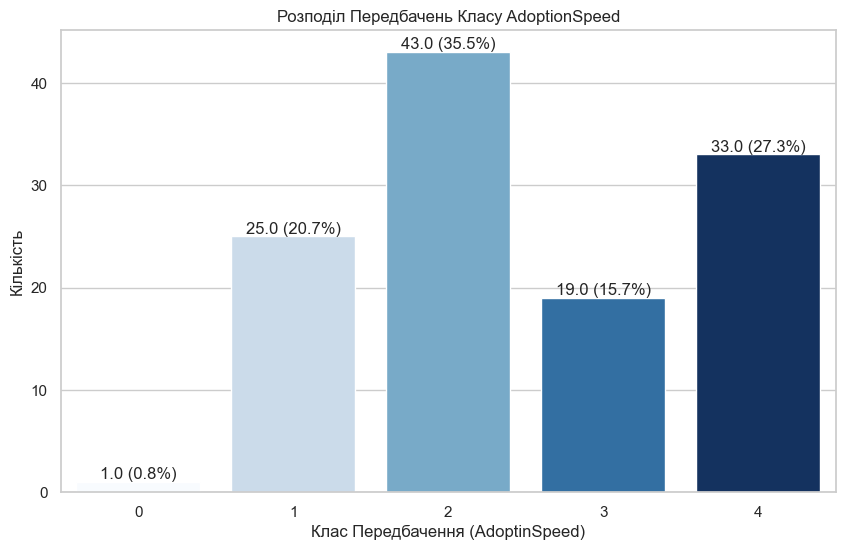

In [16]:
# Візуалізація розподілу передбачень
plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")
ax = sns.countplot(x='AdoptinSpeed_pred', data=results, hue='AdoptinSpeed_pred', palette='Blues', legend=False)

total = len(results)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{count} ({100 * count / total:.1f}%)'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.xlabel('Клас Передбачення (AdoptinSpeed)')
plt.ylabel('Кількість')
plt.title('Розподіл Передбачень Класу AdoptionSpeed')
plt.savefig('../models/logs/prediction_distribution.png')
plt.show()

In [53]:
results = pd.read_csv('../data/prediction_results.csv')
dataset = pd.read_csv('../data/dataset.csv')

In [61]:

common_columns = ['Type', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'VideoAmt']

In [62]:
results[common_columns] = results[common_columns].replace(np.nan, '<missing>').astype(str)
dataset[common_columns] = dataset[common_columns].replace(np.nan, '<missing>').astype(str)


In [63]:
adoption_speeds = []


In [64]:
for _, result_row in results.iterrows():
    match_found = False
    for _, dataset_row in dataset.iterrows():
        match = True
        for col in common_columns:
            if dataset_row[col] != '<missing>' and result_row[col] != dataset_row[col]:
                match = False
                break

        if match:
            adoption_speeds.append(dataset_row['AdoptionSpeed'])
            match_found = True
            break
    
    # Якщо не знайдено збігу, додаємо NaN
    if not match_found:
        adoption_speeds.append(np.nan)


In [65]:
results['AdoptionSpeed'] = adoption_speeds


In [66]:
print(results['AdoptionSpeed'])


0      4
1      2
2      3
3      3
4      1
      ..
116    2
117    4
118    2
119    3
120    1
Name: AdoptionSpeed, Length: 121, dtype: int64


In [67]:
# Зберігаємо результат у новий файл
results.to_csv('../data/new_data_with_actual.csv', index=False)

print("Файл 'new_data_with_actual.csv' успішно створено!")

Файл 'new_data_with_actual.csv' успішно створено!


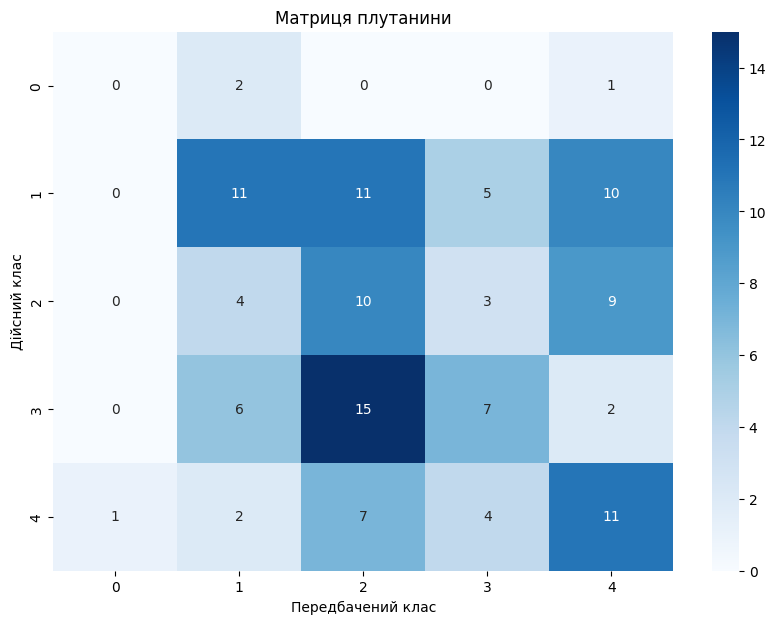

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Завантажуємо результати з реальними значеннями
results = pd.read_csv('../data/new_data_with_actual.csv')

# Виділяємо передбачення та реальні значення
predictions = results['AdoptinSpeed_pred']
actuals = results['AdoptionSpeed']

# Створюємо матрицю плутанини
conf_matrix = confusion_matrix(actuals, predictions)

# Візуалізація матриці плутанини
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Передбачений клас')
plt.ylabel('Дійсний клас')
plt.title('Матриця плутанини')

# Збереження графіка
plt.savefig('../models/logs/result_confusion_matrix.png')

plt.show()


In [70]:
from sklearn.metrics import classification_report

# Створюємо звіт з основними метриками
report = classification_report(actuals, predictions, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.44      0.30      0.35        37
           2       0.23      0.38      0.29        26
           3       0.37      0.23      0.29        30
           4       0.33      0.44      0.38        25

    accuracy                           0.32       121
   macro avg       0.27      0.27      0.26       121
weighted avg       0.34      0.32      0.32       121



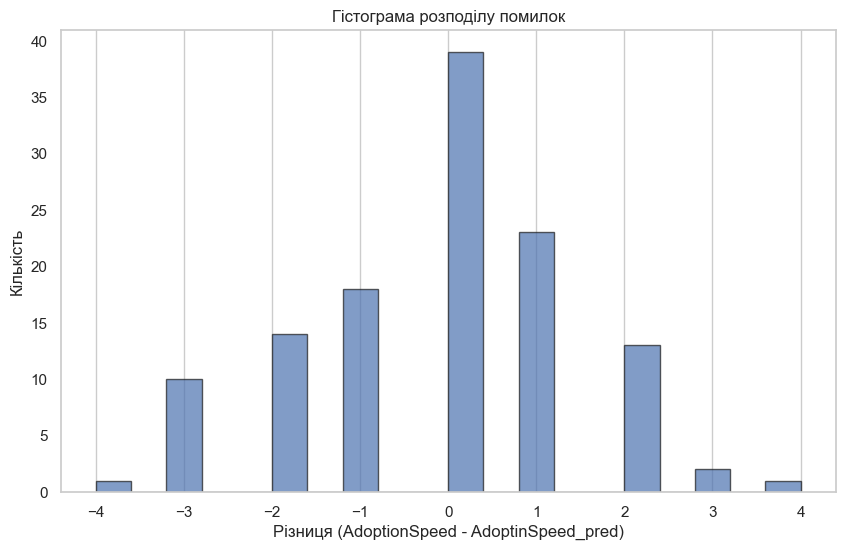

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Обчислення різниці між реальними та передбаченими значеннями
results['error'] = results['AdoptionSpeed'] - results['AdoptinSpeed_pred']

# Побудова гістограми для розподілу помилок
plt.figure(figsize=(10, 6))
plt.hist(results['error'], bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Різниця (AdoptionSpeed - AdoptinSpeed_pred)')
plt.ylabel('Кількість')
plt.title('Гістограма розподілу помилок')
plt.grid(axis='y')
plt.show()

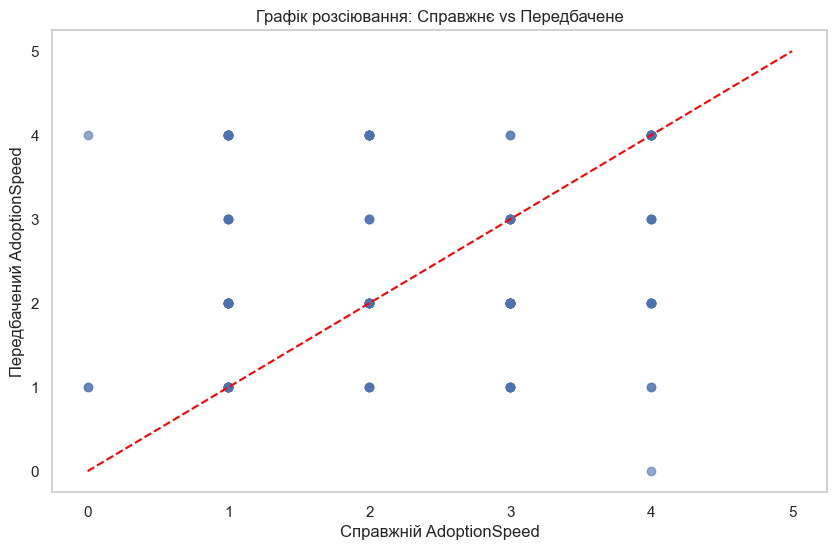

In [94]:
# Побудова графіка розсіювання
plt.figure(figsize=(10, 6))
plt.scatter(results['AdoptionSpeed'], results['AdoptinSpeed_pred'], alpha=0.6)
plt.plot([0, 5], [0, 5], color='red', linestyle='--')  # Лінія ідеального передбачення
plt.xlabel('Справжній AdoptionSpeed')
plt.ylabel('Передбачений AdoptionSpeed')
plt.title('Графік розсіювання: Справжнє vs Передбачене')
plt.grid()
plt.show()


In [95]:
# Створення зведеної таблиці для середньої помилки по різних класах ознак
group_analysis = results.pivot_table(values='error', index='Type', aggfunc='mean')
print(group_analysis)

         error
Type          
1    -0.592593
2     0.164179


In [96]:
# Сортування для виявлення найбільших помилок моделі
biggest_errors = results.loc[results['error'].abs().sort_values(ascending=False).head(10).index]
print(biggest_errors[['AdoptionSpeed', 'AdoptinSpeed_pred', 'error']])


     AdoptionSpeed  AdoptinSpeed_pred  error
34               0                  4     -4
86               4                  0      4
15               1                  4     -3
18               1                  4     -3
16               1                  4     -3
82               1                  4     -3
13               1                  4     -3
72               1                  4     -3
70               1                  4     -3
110              4                  1      3


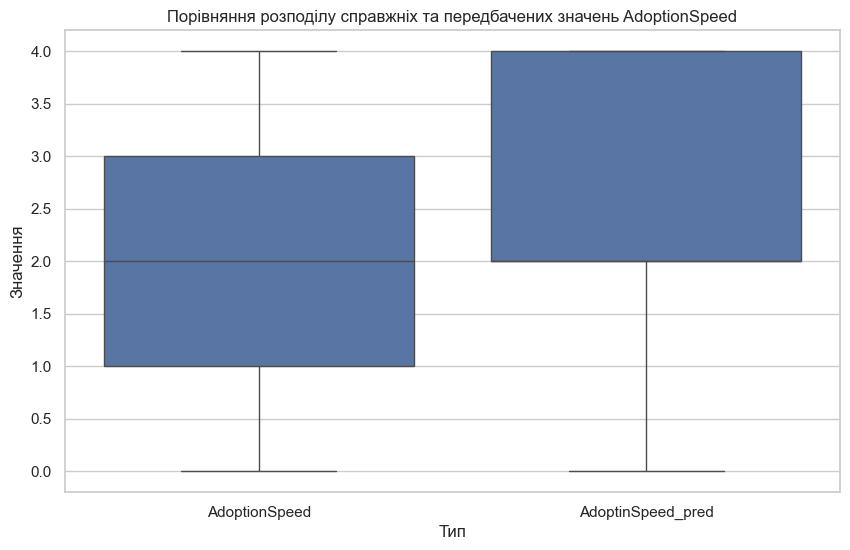

In [99]:
import seaborn as sns

# Створення двох різних наборів даних для побудови boxplot
data_to_plot = pd.melt(results[['AdoptionSpeed', 'AdoptinSpeed_pred']], var_name='Тип', value_name='Значення')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Тип', y='Значення', data=data_to_plot)
plt.title('Порівняння розподілу справжніх та передбачених значень AdoptionSpeed')
plt.show()


In [100]:
from sklearn.metrics import classification_report

# Вивід метрик точності, повноти, F1-міри
report = classification_report(results['AdoptionSpeed'], results['AdoptinSpeed_pred'], zero_division=0)
print(report)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.44      0.30      0.35        37
           2       0.23      0.38      0.29        26
           3       0.37      0.23      0.29        30
           4       0.33      0.44      0.38        25

    accuracy                           0.32       121
   macro avg       0.27      0.27      0.26       121
weighted avg       0.34      0.32      0.32       121



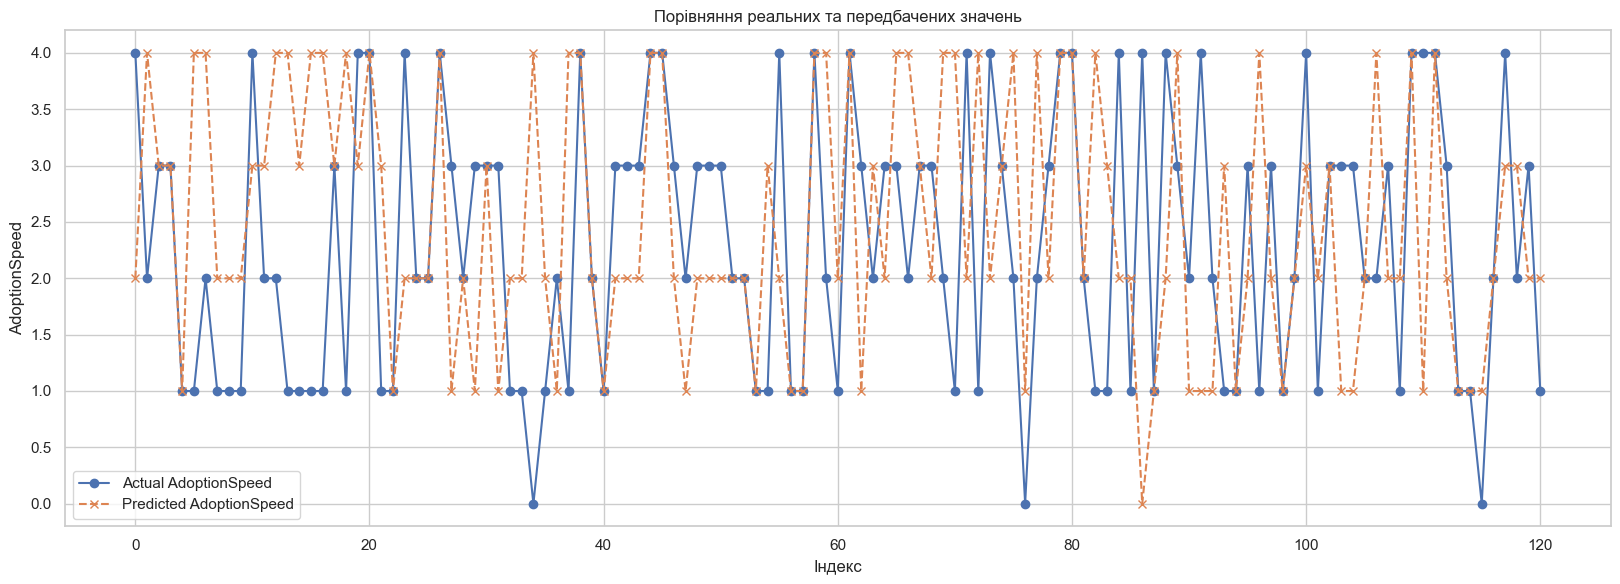

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю діаграм
sns.set(style="whitegrid")

# Побудова діаграми порівняння реальних та передбачених значень AdoptionSpeed
plt.figure(figsize=(32, 6))

# 2. Смуговий графік для порівняння реальних та передбачених значень по індексу
plt.subplot(1, 2, 2)
plt.plot(results.index, results['AdoptionSpeed'], label='Actual AdoptionSpeed', marker='o', linestyle='-')
plt.plot(results.index, results['AdoptinSpeed_pred'], label='Predicted AdoptionSpeed', marker='x', linestyle='--')
plt.title('Порівняння реальних та передбачених значень')
plt.xlabel('Індекс')
plt.ylabel('AdoptionSpeed')
plt.legend()

plt.tight_layout()
plt.show()


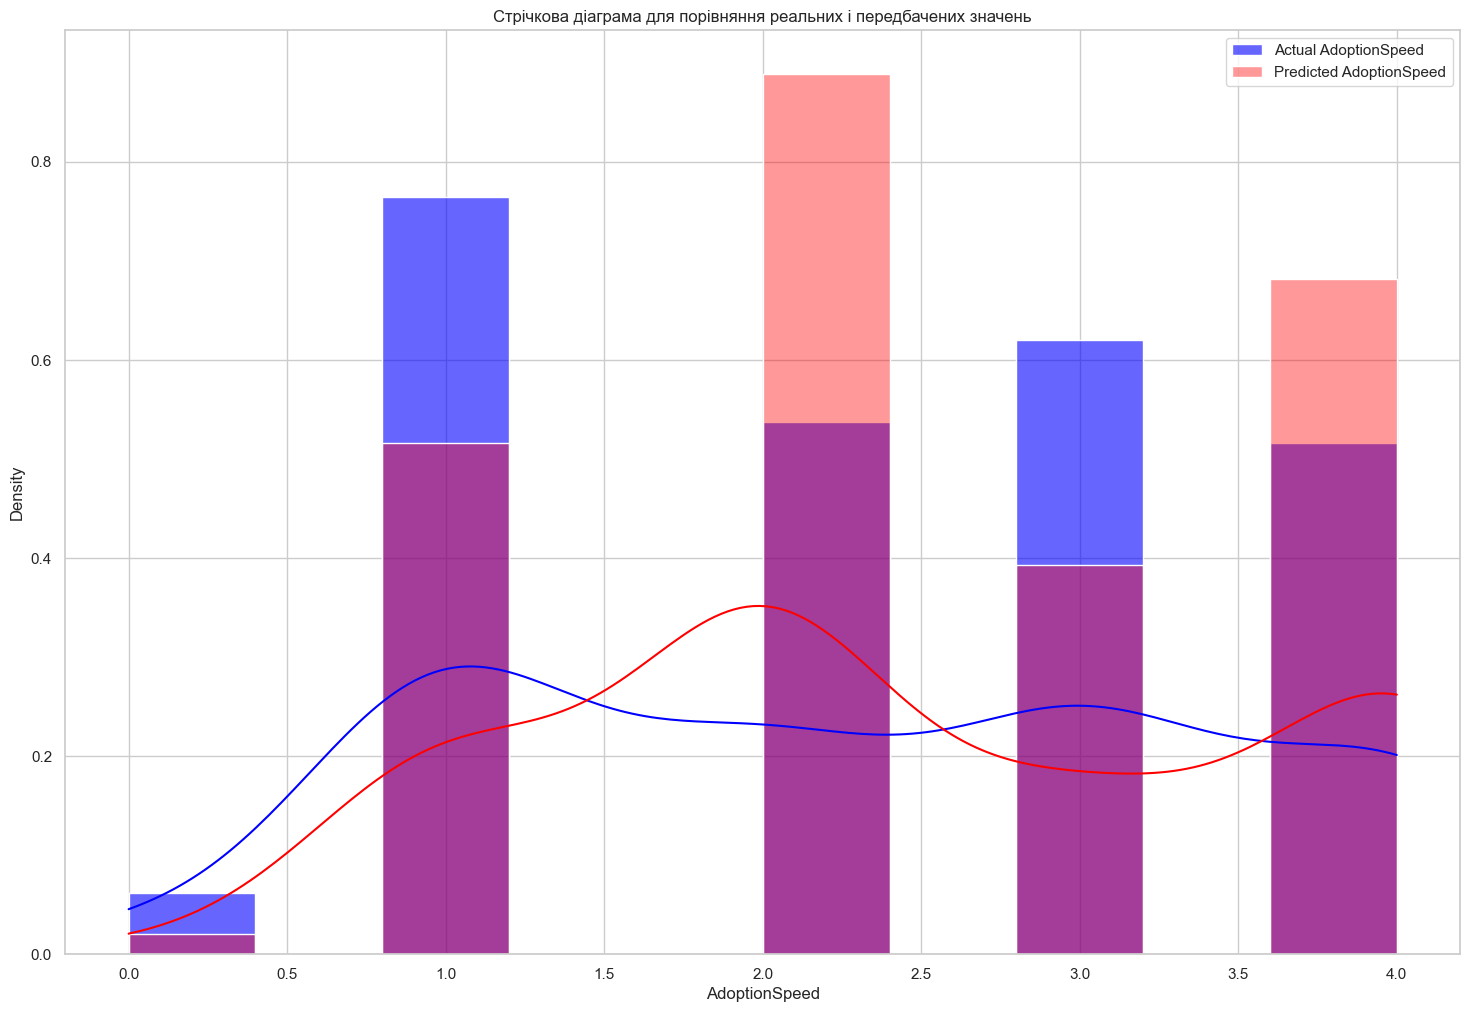

In [110]:

# Налаштування стилю діаграм
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# 2. Стрічкова діаграма для реальних та передбачених значень AdoptionSpeed
sns.histplot(results['AdoptionSpeed'], color='blue', label='Actual AdoptionSpeed', kde=True, stat="density", bins=10, alpha=0.6)
sns.histplot(results['AdoptinSpeed_pred'], color='red', label='Predicted AdoptionSpeed', kde=True, stat="density", bins=10, alpha=0.4)
plt.legend()
plt.title('Стрічкова діаграма для порівняння реальних і передбачених значень')

# Збереження діаграми у файл
plt.savefig('../models/logs/comparison_histogram.png')
